<a href="https://colab.research.google.com/github/alt-gabby/qml-assignments/blob/main/3_QAQO_for_Max_Cut.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install pennylane

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.3/57.3 kB 810.7 kB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.4/5.4 MB 15.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 937.5/937.5 kB 46.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 25.5/25.5 MB 38.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.4/2.4 MB 85.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 167.2/167.2 kB 15.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.8/8.8 MB 41.9 MB/s eta 0:00:00


# Generate a random graph

In [24]:
import networkx as nx
import numpy as np
import pennylane as qml
import itertools
import matplotlib.pyplot as plt
from scipy.optimize import minimize

np.random.seed(42)

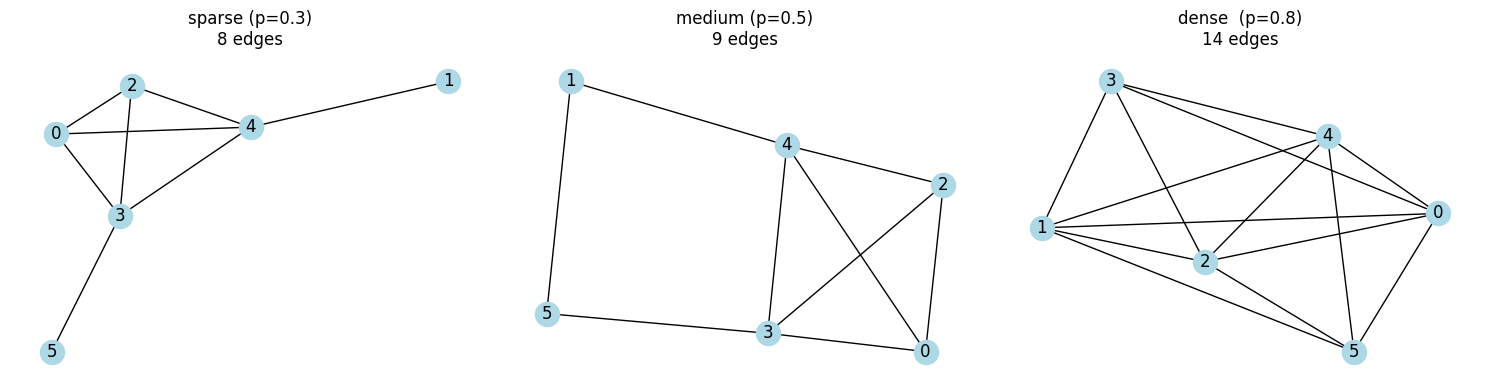

In [34]:
# Generate random graphs with different topologies
def generate_graph(n, p_edge=0.5, seed=None):
    return nx.gnp_random_graph(n, p_edge, seed=seed)

graphs = {
    "sparse (p=0.3)": generate_graph(6, p_edge=0.3, seed=42),
    "medium (p=0.5)": generate_graph(6, p_edge=0.5, seed=42),
    "dense  (p=0.8)": generate_graph(6, p_edge=0.8, seed=7),
}

# Visualize the graphs
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, (name, G) in zip(axes, graphs.items()):
    nx.draw(G, ax=ax, with_labels=True, node_color="lightblue")
    ax.set_title(f"{name}\n{G.number_of_edges()} edges")
plt.tight_layout()
plt.show()

# Build QAOA Hamiltonians


In [35]:
# Exact MaxCut via brute force
def brute_maxcut(G):
    n = len(G.nodes)
    best = 0
    for bits in itertools.product([0, 1], repeat=n):
        cut = sum(1 for i, j in G.edges if bits[i] != bits[j])
        best = max(best, cut)
    return best

# Full QAOA circuit

In [36]:
# QAOA circuit
dev = qml.device("default.qubit", wires=6)

def qaoa_layer(gamma, beta, G):
    # Cost unitary: e^{-i gamma H_C}
    for i, j in G.edges:
        qml.CNOT(wires=[i, j])
        qml.RZ(2 * gamma, wires=j)
        qml.CNOT(wires=[i, j])
    # Mixer unitary: e^{-i beta H_B}
    for i in G.nodes:
        qml.RX(2 * beta, wires=i)

def qaoa_circuit(params, G, p):
    gammas = params[:p]
    betas  = params[p:]
    # Prepare |+>^n
    for i in G.nodes:
        qml.Hadamard(wires=i)
    for layer in range(p):
        qaoa_layer(gammas[layer], betas[layer], G)

# Define cost function

In [37]:

def make_cost_function(G, p):
   # Build Hamiltonian: H_C = sum_{(i,j) in E} 0.5*(I - Z_i Z_j)
    # Minimizing -<H_C> is equivalent to maximizing the cut
    coeffs = [0.5] * len(list(G.edges))
    obs    = [qml.PauliZ(i) @ qml.PauliZ(j) for i, j in G.edges]
    H_cost = qml.Hamiltonian(coeffs, obs)

    @qml.qnode(dev)
    def cost_fn(params):
        qaoa_circuit(params, G, p)
        return qml.expval(H_cost)

    return cost_fn

#Optimization loop

In [33]:
# Optimization loop
def run_qaoa(G, p, n_restarts=3):
    best_val, best_params = np.inf, None

    for _ in range(n_restarts):
        init_params = np.random.uniform(0, np.pi, 2 * p)
        cost_fn = make_cost_function(G, p)

        result = minimize(
            cost_fn,
            init_params,
            method="COBYLA",
            options={"maxiter": 1000}
        )

        if result.fun < best_val:
            best_val   = result.fun
            best_params = result.x

    # cost_fn returns -<cut>, so negate to get cut value
    cut_value = -best_val + 0.5 * len(list(G.edges))
    return cut_value, best_params

In [38]:
# Run QAOA across all graphs and depths, compute approximation ratios
depths = [1, 2, 3]
results = {}

for name, G in graphs.items():
    C_exact = brute_maxcut(G)
    results[name] = {"exact": C_exact, "qaoa": {}, "ratio": {}}

    print(f"\nGraph: {name} | Exact MaxCut: {C_exact}")
    for p in depths:
        C_qaoa, _ = run_qaoa(G, p)
        ratio = C_qaoa / C_exact
        results[name]["qaoa"][p]  = C_qaoa
        results[name]["ratio"][p] = ratio
        print(f"  p={p}  QAOA cut={C_qaoa:.3f}  ratio={ratio:.3f}")


Graph: sparse (p=0.3) | Exact MaxCut: 6
  p=1  QAOA cut=5.054  ratio=0.842
  p=2  QAOA cut=5.503  ratio=0.917
  p=3  QAOA cut=5.833  ratio=0.972

Graph: medium (p=0.5) | Exact MaxCut: 7
  p=1  QAOA cut=5.730  ratio=0.819
  p=2  QAOA cut=6.153  ratio=0.879
  p=3  QAOA cut=6.574  ratio=0.939

Graph: dense  (p=0.8) | Exact MaxCut: 9
  p=1  QAOA cut=8.150  ratio=0.906
  p=2  QAOA cut=8.440  ratio=0.938
  p=3  QAOA cut=8.527  ratio=0.947


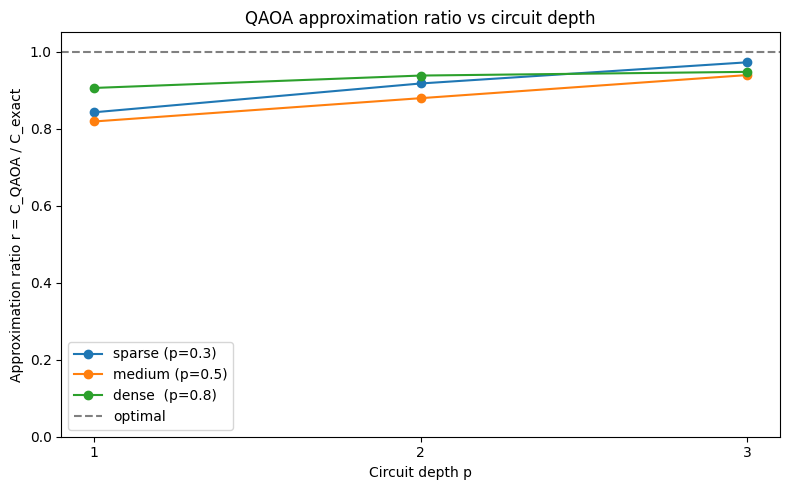

In [39]:
# Plot approximation ratios across depths and graph topologies
fig, ax = plt.subplots(figsize=(8, 5))

for name in graphs:
    ratios = [results[name]["ratio"][p] for p in depths]
    ax.plot(depths, ratios, marker="o", label=name)

ax.set_xlabel("Circuit depth p")
ax.set_ylabel("Approximation ratio r = C_QAOA / C_exact")
ax.set_title("QAOA approximation ratio vs circuit depth")
ax.set_xticks(depths)
ax.set_ylim(0, 1.05)
ax.axhline(1.0, color="gray", linestyle="--", label="optimal")
ax.legend()
plt.tight_layout()
plt.show()